<div style="border-left:4px solid #3D6FB0;padding:6px 0 8px 16px;"><div style="opacity:.72;font-size:12px;letter-spacing:1.4px;">DATOS MASIVOS II · PRÁCTICA</div><div style="color:#3D6FB0;font-size:27px;font-weight:700;margin-top:4px;">Reglas de asociación en el Titanic con FP-Growth</div><div style="opacity:.72;font-size:14px;margin-top:6px;">Patrones frecuentes y reglas interpretables sobre los pasajeros, a partir del dataset transaccional del notebook 01_edacalidad_preprocesamiento.</div><div style="opacity:.72;font-size:14px;margin-top:6px;margin-bottom:10px;">Equipo Tres: Castrillo Cruz Karen Arlet, Ramos González Nadia, Zamora Antiga Ángel Javier.</div><img src="https://mmss.iimas.unam.mx/dmmss/wp-content/uploads/2026/02/cropped-LogoUNAM_IIMAS_Negro50-scaled-2.png" width="200"/></div>

### Objetivo

Encontrar **patrones frecuentes** y **reglas de asociación** interpretables entre las características de los pasajeros del Titanic (clase, sexo, edad, tarifa, puerto y tamaño de familia) y su supervivencia, usando el algoritmo **FP-Growth**. No es un problema de clasificación: no se entrena un modelo ni se predice `Survived`, sino que se describen las co-ocurrencias que aparecen en los datos.

### Los datos

Dataset *Titanic – Machine Learning from Disaster* de Kaggle: https://www.kaggle.com/competitions/titanic/data

Se usan los archivos generados por el notebook 1 (`01_eda_calidad_preprocesamiento.ipynb`) a partir de `train.csv`: 891 pasajeros, 7 atributos discretizados y 22 ítems. Este notebook **no limpia ni transforma datos**: solo los carga.


<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">MINERÍA · PREPARACIÓN</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">0. Preparación y carga</span></div>

Se cargan las dos tablas exportadas por el notebook 1: la tabla one-hot booleana (una columna por ítem), que es la entrada de `mlxtend`, y la tabla categórica, que conserva la bandera `EdadImputada` para el análisis de sensibilidad.

In [1]:
# Importación de librerías y carga del dataset transaccional
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from mlxtend.frequent_patterns import fpgrowth, association_rules

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

RUTA_PROCESADOS = Path("..") / "data" / "processed"
transacciones = pd.read_csv(RUTA_PROCESADOS / "titanic_transacciones.csv")
tabla_limpia = pd.read_csv(RUTA_PROCESADOS / "titanic_limpio.csv")

print(f"Transacciones: {transacciones.shape[0]} filas x {transacciones.shape[1]} ítems | "
      f"todas booleanas: {(transacciones.dtypes == bool).all()}")
print(f"Tabla categórica: {tabla_limpia.shape[0]} filas x {tabla_limpia.shape[1]} columnas | "
      f"edades imputadas: {tabla_limpia['EdadImputada'].sum()}")
display(tabla_limpia.head())

Transacciones: 891 filas x 22 ítems | todas booleanas: True
Tabla categórica: 891 filas x 9 columnas | edades imputadas: 177


,PassengerId,Survived,Pclass,Sex,Embarked,Age,Fare,FamilySize,EdadImputada
0,1,0,3,male,S,Joven (18-29),0.00-7.91,2-4,False
1,2,1,1,female,C,Adulto (30-49),31.00-512.33,2-4,False
2,3,1,3,female,S,Joven (18-29),7.91-14.45,Solo,False
3,4,1,1,female,S,Adulto (30-49),31.00-512.33,2-4,False
4,5,0,3,male,S,Adulto (30-49),7.91-14.45,Solo,False


<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">MINERÍA · ALGORITMO</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">1. Justificación del algoritmo: FP-Growth</span></div>

La elección se apoya en las **preguntas de selección de estrategia** de la presentación *Pasadas limitadas* del curso:

| Pregunta | Respuesta para este dataset | Implicación |
|---|---|---|
| ¿El conjunto cabe en memoria? | Sí: 891 transacciones × 22 ítems booleanos (unos 110 KB en CSV) | SON y Toivonen existen para cuando **no** cabe (minimizan pasadas sobre disco); aquí no resuelven ningún problema |
| ¿Cuánto cuesta una pasada? | Prácticamente nada | La ventaja de "pocas pasadas" no es decisiva, aunque FP-Growth la tiene |
| ¿Cuántos ítems distintos hay? | 22, pero las transacciones son **densas**: cada pasajero tiene exactamente 7 ítems (densidad 0.318) | Muchos itemsets frecuentes y largos: muchos candidatos para Apriori |
| ¿Qué tan bajo es el soporte mínimo? | Bajo (5 % y, en una corrida complementaria, 2 %) para captar subgrupos | Al bajar $s$ crecen los candidatos y el costo: el punto débil de Apriori |
| ¿Hay que particionar o paralelizar? | No | SON queda descartado |
| ¿Se necesita un resultado exacto? | Sí | FP-Growth es exacto y no tiene el riesgo de reinicio de Toivonen |

**FP-Growth frente a Apriori** (presentación de FP-Growth, *FP-Growth vs A-priori*):
- FP-Growth hace **2 pasadas** sobre los datos (contar ítems y construir el FP-tree), contra $K_{max} + 1$ de Apriori.
- **No genera candidatos**: extrae los itemsets frecuentes recorriendo el árbol de prefijos.
- **Optimiza memoria y es más rápido**, sobre todo con datos densos y soportes bajos, como aquí.
- Su desventaja, que si la base cambia hay que reconstruir el árbol, **no aplica**: el dataset es estático (datos históricos de 1912).

**Comparación de los algoritmos del curso:**

| Algoritmo | Idea | Pasadas | ¿Genera candidatos? | ¿Exacto? | ¿Conviene aquí? |
|---|---|---|---|---|---|
| Apriori | Genera candidatos de tamaño $k$ a partir de los frecuentes de tamaño $k-1$ (monotonía del soporte) | $K_{max} + 1$ | Sí | Sí | Funciona, pero con datos densos y soporte bajo genera muchos candidatos |
| **FP-Growth** | Comprime las transacciones en un FP-tree y extrae patrones por crecimiento de prefijos | **2** | **No** | **Sí** | **Sí: exacto, eficiente con datos densos y soportes bajos** |
| PrefixSpan | Proyecciones por prefijo para patrones **secuenciales** | Varias | No | Sí | No: supone orden entre ítems, y cada pasajero es un registro sin orden |
| SON | Divide los datos en particiones que caben en memoria y une los frecuentes locales | 2 | Sí (candidatos locales) | Sí | No: los datos caben en memoria; no hay nada que particionar |
| Toivonen | Muestra + frontera negativa para verificar en una pasada | 1–2 (puede reiniciar) | Sí | Sí, si no hay reinicio | No: muestrear no tiene sentido con 891 filas y existe riesgo de reinicio |

Bibliografía: Leskovec, Rajaraman y Ullman, *Mining of Massive Datasets*; Aggarwal, *Data Mining: The Textbook* (2015); Han, Pei y Yin (2000), *Mining Frequent Patterns without Candidate Generation*.

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">MINERÍA · DESCRIPCIÓN</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">2. Descripción de las transacciones</span></div>

Antes de minar se describe el conjunto: tamaño, densidad y **soporte** de cada ítem. El soporte de un itemset $X$ es la fracción de transacciones que lo contienen:

$$\text{sop}(X) = \frac{|\{t \in T : X \subseteq t\}|}{|T|}$$

Un itemset es **frecuente** si $\text{sop}(X) \geq s$, el soporte mínimo. Por la propiedad de monotonía, ningún itemset puede tener más soporte que cualquiera de sus ítems, así que los ítems con soporte menor que $s$ nunca aparecerán en un itemset frecuente.

Transacciones: 891 | ítems distintos: 22 | ítems por transacción: 7–7 | densidad: 0.3182


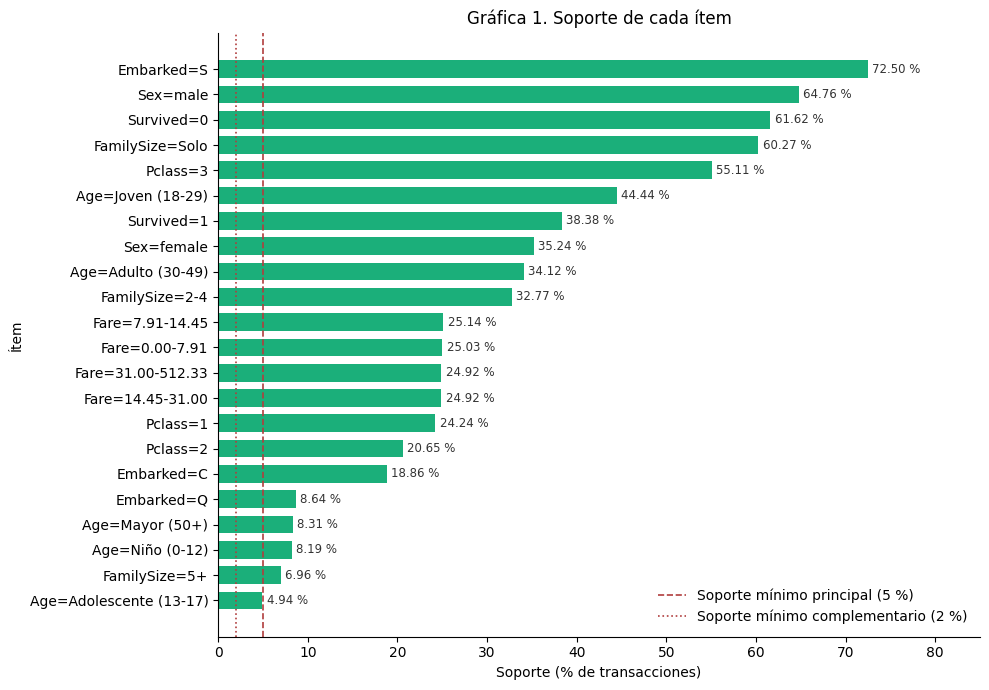

Ítems con soporte < 5 %: ['Age=Adolescente (13-17)']
Ítems con soporte > 50 %: {'Embarked=S': 0.725, 'Sex=male': 0.6476, 'Survived=0': 0.6162, 'FamilySize=Solo': 0.6027, 'Pclass=3': 0.5511}


In [2]:
# Tamaño, densidad y soporte de cada ítem
n_trans, n_items = transacciones.shape
items_por_trans = transacciones.sum(axis=1)
print(f"Transacciones: {n_trans} | ítems distintos: {n_items} | ítems por transacción: "
      f"{items_por_trans.min()}–{items_por_trans.max()} | densidad: {transacciones.values.mean():.4f}")

soporte_item = transacciones.mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
barras = ax.barh(soporte_item.index, soporte_item.values * 100, color="#1baf7a", height=0.7)
for et in ax.bar_label(barras, labels=[f"{v * 100:.2f} %" for v in soporte_item.values], padding=3, fontsize=8.5,
                       color="#333333"):
    et.set_bbox(dict(facecolor="white", edgecolor="none", pad=1))
ax.axvline(5, color="#B03D3D", linestyle="--", linewidth=1.2, label="Soporte mínimo principal (5 %)")
ax.axvline(2, color="#B03D3D", linestyle=":", linewidth=1.2, label="Soporte mínimo complementario (2 %)")
ax.set_title("Gráfica 1. Soporte de cada ítem")
ax.set_xlabel("Soporte (% de transacciones)")
ax.set_ylabel("Ítem")
ax.set_xlim(0, 85)
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Ítems con soporte < 5 %: {soporte_item[soporte_item < 0.05].index.tolist()}")
print(f"Ítems con soporte > 50 %: {soporte_item[soporte_item > 0.5].sort_values(ascending=False).round(4).to_dict()}")

**Observaciones: descripción de las transacciones**

- **891 transacciones y 22 ítems.** Cada transacción tiene **exactamente 7 ítems**, uno por atributo, y la **densidad es 0.3182**. Son transacciones densas y de longitud fija, un escenario favorable para FP-Growth: el FP-tree comprime bien prefijos muy repetidos.
- **Cinco ítems superan el 50 % de soporte:** `Embarked=S` (**72.50 %**), `Sex=male` (**64.76 %**), `Survived=0` (**61.62 %**), `FamilySize=Solo` (**60.27 %**) y `Pclass=3` (**55.11 %**).
  - Aparecerán en muchísimos itemsets, y cualquier regla con uno de ellos como consecuente tendrá una confianza alta por defecto. Por eso se usará **lift**.
- **Solo `Age=Adolescente (13-17)` (4.94 %) queda por debajo del 5 %.** No aparecerá en ningún itemset del análisis principal, pero sí en la corrida complementaria al 2 %.

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">MINERÍA · UMBRALES</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">3. Elección del soporte mínimo: análisis de sensibilidad</span></div>

El soporte mínimo $s$ controla el equilibrio entre **cantidad** y **robustez**. Un $s$ alto deja pocos itemsets, todos respaldados por muchos pasajeros. Un $s$ bajo capta subgrupos pequeños, pero multiplica los itemsets y las reglas, y produce patrones con menos respaldo. Se ejecuta FP-Growth con varios valores de $s$ y se cuentan los itemsets frecuentes y las reglas resultantes (con confianza mínima de 0.6, definida en la sección 5).

,Itemsets frecuentes,Longitud máxima,Reglas (conf ≥ 0.6),Reglas → Survived=1,Reglas → Survived=0
min_support,,,,,
0.02,1519,7,4118,161,332
0.03,1028,7,2530,100,231
0.04,733,7,1837,66,179
0.05,569,7,1538,44,152
0.07,389,7,1091,20,111
0.10,233,6,703,8,75
0.15,126,5,347,3,42
0.20,73,4,152,1,22


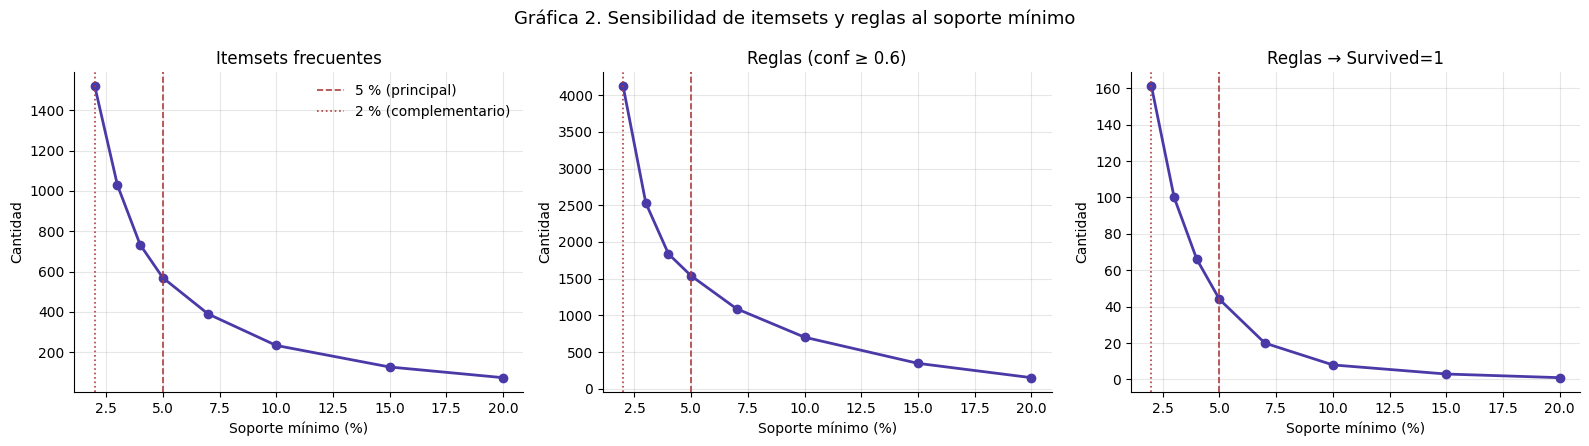

,Soporte (%)
Itemset,
"Sex=female, Pclass=1, Survived=1",10.21
"Sex=female, Pclass=3, Survived=0",8.08
"FamilySize=5+, Survived=0",5.84
"Embarked=Q, Survived=1",3.37
"Sex=male, Age=Niño (0-12), Survived=1",2.58


In [3]:
# Sensibilidad: número de itemsets y reglas según el soporte mínimo
def es_consecuente(reglas, item):
    """
    Indica qué reglas tienen exactamente un ítem dado como consecuente.

    Parámetros
    ----------
    reglas : pd.DataFrame
        Salida de `association_rules`.
    item : str
        Ítem buscado, p. ej. "Survived=1".

    Retorna
    -------
    pd.Series
        Serie booleana alineada con `reglas`.
    """
    return reglas["consequents"] == frozenset({item})


CONF_MIN = 0.6
filas = []
for s in [0.02, 0.03, 0.04, 0.05, 0.07, 0.10, 0.15, 0.20]:
    fi = fpgrowth(transacciones, min_support=s, use_colnames=True)
    r = association_rules(fi, metric="confidence", min_threshold=CONF_MIN)
    filas.append({"min_support": s, "Itemsets frecuentes": len(fi), "Longitud máxima": fi["itemsets"].map(len).max(),
                  "Reglas (conf ≥ 0.6)": len(r), "Reglas → Survived=1": int(es_consecuente(r, "Survived=1").sum()),
                  "Reglas → Survived=0": int(es_consecuente(r, "Survived=0").sum())})
sensibilidad = pd.DataFrame(filas).set_index("min_support")
display(sensibilidad)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ["Itemsets frecuentes", "Reglas (conf ≥ 0.6)", "Reglas → Survived=1"]):
    ax.plot(sensibilidad.index * 100, sensibilidad[col], color="#4a3aa7", marker="o", linewidth=2, markersize=6)
    for s, estilo, etiqueta in [(5, "--", "5 % (principal)"), (2, ":", "2 % (complementario)")]:
        ax.axvline(s, color="#B03D3D", linestyle=estilo, linewidth=1.2, label=etiqueta)
    ax.set_title(col)
    ax.set_xlabel("Soporte mínimo (%)")
    ax.set_ylabel("Cantidad")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.3)
axes[0].legend(frameon=False)
fig.suptitle("Gráfica 2. Sensibilidad de itemsets y reglas al soporte mínimo", fontsize=13)
plt.tight_layout()
plt.show()

# Patrones de interés del EDA y su soporte
soporte_de = lambda items: transacciones[list(items)].all(axis=1).mean()
patrones = [["Sex=female", "Pclass=1", "Survived=1"], ["Sex=female", "Pclass=3", "Survived=0"],
            ["FamilySize=5+", "Survived=0"], ["Embarked=Q", "Survived=1"], ["Sex=male", "Age=Niño (0-12)", "Survived=1"]]
display(pd.DataFrame({"Itemset": [", ".join(p) for p in patrones],
                      "Soporte (%)": [round(soporte_de(p) * 100, 2) for p in patrones]}).set_index("Itemset"))

**Observaciones y decisión: soporte mínimo**

- **La curva cae rápido al principio y luego se aplana:**
  - de **1519** itemsets al 2 % se pasa a **569** al 5 % y a **233** al 10 %;
  - las reglas con confianza ≥ 0.6 bajan de **4118** a **1538** y a **703**.
- **Las reglas → `Survived=1` son las más sensibles:** **161** al 2 %, **44** al 5 %, **8** al 10 % y **1** al 20 %. Las reglas hacia `Survived=0` siempre son más (**152** al 5 %) por el desbalance (61.62 % contra 38.38 %).
- **Soporte de los patrones de interés detectados en el EDA:**
  - `{Sex=female, Pclass=1, Survived=1}` (**10.21 %**) y `{Sex=female, Pclass=3, Survived=0}` (**8.08 %**) sobreviven incluso con $s$ = 7 %;
  - `{FamilySize=5+, Survived=0}` (**5.84 %**) apenas pasa el 5 %;
  - `{Embarked=Q, Survived=1}` (**3.37 %**) y `{Sex=male, Age=Niño, Survived=1}` (**2.58 %**, el efecto de "niños primero") **solo aparecen por debajo del 5 %**.

**Decisión:**
- **Análisis principal con $s$ = 5 %:** 569 itemsets y 1538 reglas, un volumen manejable con patrones respaldados por al menos 45 pasajeros.
- **Corrida complementaria con $s$ = 2 %**, restringida a reglas con consecuente `Survived`, para recuperar subgrupos pequeños pero relevantes, como los niños varones. Las reglas que solo aparecen ahí se tratan como **evidencia débil**, porque se apoyan en 18 pasajeros o menos.

| Alternativa | Razón para descartarla |
|---|---|
| Solo $s$ = 5 % | Pierde el patrón de los niños varones, uno de los hallazgos del EDA (gráfica 6 del notebook 1). |
| $s$ = 10 % | Solo 8 reglas → `Survived=1`; pierde `Embarked=Q`, `FamilySize=5+` y los niños. |
| $s$ = 2 % para todo | 4118 reglas: muchas con soporte de unas pocas decenas de pasajeros, difíciles de revisar y menos robustas. |

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">MINERÍA · FP-GROWTH</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">4. Itemsets frecuentes con FP-Growth</span></div>

Se ejecuta `mlxtend.frequent_patterns.fpgrowth` con $s$ = 0.05 sobre la tabla one-hot. El algoritmo hace una primera pasada para contar el soporte de cada ítem y una segunda para construir el FP-tree, y luego extrae los itemsets frecuentes por crecimiento de patrones, sin generar candidatos.

In [4]:
# Itemsets frecuentes con FP-Growth (min_support = 0.05)
MIN_SUP = 0.05
itemsets = fpgrowth(transacciones, min_support=MIN_SUP, use_colnames=True)
itemsets["Longitud"] = itemsets["itemsets"].map(len)
print(f"Itemsets frecuentes con min_support = {MIN_SUP}: {len(itemsets)}")

por_longitud = itemsets.groupby("Longitud").agg(Itemsets=("support", "size"),
                                                Soporte_máximo=("support", "max"),
                                                Soporte_mínimo=("support", "min")).round(4)
display(por_longitud)


def formatear(itemset):
    """
    Convierte un frozenset de ítems en texto legible y ordenado.

    Parámetros
    ----------
    itemset : frozenset
        Conjunto de ítems.

    Retorna
    -------
    str
        Ítems ordenados alfabéticamente, separados por coma.
    """
    return ", ".join(sorted(itemset))


# Los itemsets más frecuentes de longitud 2 y 3
for k in [2, 3]:
    top = (itemsets[itemsets["Longitud"] == k].nlargest(8, "support")
           .assign(Itemset=lambda d: d["itemsets"].map(formatear), **{"Soporte (%)": lambda d: (d["support"] * 100).round(2)}))
    display(top[["Itemset", "Soporte (%)"]].set_index("Itemset")
            .style.format("{:.2f}").set_caption(f"Itemsets de longitud {k} con mayor soporte"))

# Itemsets frecuentes que contienen Survived=1
con_s1 = itemsets[itemsets["itemsets"].map(lambda s: "Survived=1" in s) & (itemsets["Longitud"] >= 2)]
print(f"Itemsets frecuentes que contienen Survived=1 (longitud ≥ 2): {len(con_s1)}")
display(con_s1.nlargest(10, "support").assign(Itemset=lambda d: d["itemsets"].map(formatear),
                                               **{"Soporte (%)": lambda d: (d["support"] * 100).round(2)})
        [["Itemset", "Soporte (%)"]].set_index("Itemset"))

# El itemset más largo
print(f"Itemset de longitud 7: {formatear(itemsets.loc[itemsets['Longitud'] == 7, 'itemsets'].iloc[0])} "
      f"(soporte {itemsets.loc[itemsets['Longitud'] == 7, 'support'].iloc[0] * 100:.2f} %)")

Itemsets frecuentes con min_support = 0.05: 569


,Itemsets,Soporte_máximo,Soporte_mínimo
Longitud,,,
1,21,0.7250,0.0696
2,122,0.5253,0.0527
3,228,0.4085,0.0505
4,133,0.3064,0.0505
5,50,0.1987,0.0505
6,14,0.1324,0.0505
7,1,0.0741,0.0741


,Soporte (%)
Itemset,
"Sex=male, Survived=0",52.53
"Embarked=S, Sex=male",49.49
"Embarked=S, Survived=0",47.92
"FamilySize=Solo, Sex=male",46.13
"Embarked=S, FamilySize=Solo",44.33
"FamilySize=Solo, Survived=0",41.98
"Pclass=3, Survived=0",41.75
"Embarked=S, Pclass=3",39.62


,Soporte (%)
Itemset,
"Embarked=S, Sex=male, Survived=0",40.85
"FamilySize=Solo, Sex=male, Survived=0",38.95
"Embarked=S, FamilySize=Solo, Sex=male",36.03
"Pclass=3, Sex=male, Survived=0",33.67
"Embarked=S, FamilySize=Solo, Survived=0",32.77
"Embarked=S, Pclass=3, Survived=0",32.10
"Embarked=S, Pclass=3, Sex=male",29.74
"FamilySize=Solo, Pclass=3, Sex=male",29.63


Itemsets frecuentes que contienen Survived=1 (longitud ≥ 2): 86


,Soporte (%)
Itemset,
"Sex=female, Survived=1",26.15
"Embarked=S, Survived=1",24.58
"FamilySize=2-4, Survived=1",18.97
"FamilySize=Solo, Survived=1",18.29
"Embarked=S, Sex=female, Survived=1",15.94
"Pclass=1, Survived=1",15.26
"Age=Adulto (30-49), Survived=1",14.48
"Fare=31.00-512.33, Survived=1",14.48
"FamilySize=2-4, Sex=female, Survived=1",14.03


Itemset de longitud 7: Age=Joven (18-29), Embarked=S, FamilySize=Solo, Fare=0.00-7.91, Pclass=3, Sex=male, Survived=0 (soporte 7.41 %)


**Observaciones: itemsets frecuentes**

- **569 itemsets frecuentes con $s$ = 5 %:**

  | Longitud | 1 | 2 | 3 | 4 | 5 | 6 | 7 |
  |---|---|---|---|---|---|---|---|
  | Itemsets | 21 | 122 | **228** | 133 | 50 | 14 | 1 |

  - De longitud 1 hay **21** de los 22 ítems: `Age=Adolescente` queda fuera.
  - La distribución se concentra en longitud **3**. Que existan itemsets de longitud 6 y 7 refleja la densidad de los datos: con Apriori habría que generar candidatos durante 7 pasadas.
- **El único itemset de longitud 7 (soporte 7.41 %) es un "pasajero tipo" completo:** `{Age=Joven (18-29), Embarked=S, FamilySize=Solo, Fare=0.00-7.91, Pclass=3, Sex=male, Survived=0}`. Hay **66** pasajeros idénticos en los 7 atributos: hombres jóvenes de 3.ª clase que viajaban solos con la tarifa más baja y no sobrevivieron.
- **Los itemsets de mayor soporte combinan ítems dominantes:**
  - longitud 2: `{Sex=male, Survived=0}` (**52.53 %**), `{Embarked=S, Sex=male}` (**49.49 %**);
  - longitud 3: `{Embarked=S, Sex=male, Survived=0}` (**40.85 %**).

  Son frecuentes porque sus ítems lo son, no necesariamente porque estén asociados.
- **86 itemsets frecuentes de longitud ≥ 2 contienen `Survived=1`.** Los de mayor soporte son `{Sex=female, Survived=1}` (**26.15 %**) y `{Pclass=1, Survived=1}` (**15.26 %**). Aparecen también combinaciones con ítems dominantes, como `{Embarked=S, Survived=1}` (**24.58 %**), cuyo interés real solo se puede juzgar con el lift (sección 5).

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">MINERÍA · REGLAS</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">5. Reglas de asociación</span></div>

Una regla $A \rightarrow C$ (antecedente → consecuente) se genera a partir de cada itemset frecuente $A \cup C$. Siguiendo el procedimiento de la presentación *Memoria principal*: se generan las reglas candidatas, se calcula su confianza, se aplica un umbral, y se ordenan y presentan. Las métricas que se usan son:

$$\text{conf}(A \rightarrow C) = \frac{\text{sop}(A \cup C)}{\text{sop}(A)} \qquad \text{lift}(A \rightarrow C) = \frac{\text{conf}(A \rightarrow C)}{\text{sop}(C)}$$

$$\text{leverage}(A \rightarrow C) = \text{sop}(A \cup C) - \text{sop}(A)\,\text{sop}(C) \qquad \text{conviction}(A \rightarrow C) = \frac{1 - \text{sop}(C)}{1 - \text{conf}(A \rightarrow C)}$$

- La **confianza** estima $P(C \mid A)$, pero depende del soporte del consecuente: con ítems dominantes como `Embarked=S` (72.50 %), casi cualquier regla tiene confianza alta.
- El **lift** corrige eso: $\text{lift} > 1$ indica que $A$ y $C$ aparecen juntos más de lo esperado bajo independencia. Es la métrica principal para ordenar.
- El **leverage** mide la misma desviación en escala absoluta (proporción de transacciones), y la **conviction** crece cuando la regla casi nunca falla.

**Umbrales:** confianza mínima **0.6** y lift **> 1**. Además se marcan como **triviales** las reglas que solo relacionan `Fare` con `Pclass`, porque reflejan la redundancia detectada en el notebook 1 (V de Cramér = 0.54).

Reglas candidatas con confianza ≥ 0.6: 1538


,Reglas
Reglas con conf ≥ 0.6,1538
con lift > 1,1458
con lift ≤ 1 (asociación nula o negativa),80
triviales Fare/Pclass,4
con consecuente Survived=1,44
con consecuente Survived=0,152


Antecedente,Consecuente,support,confidence,lift,leverage,conviction
Fare=0.00-7.91,Pclass=3,0.237,0.946,1.72,0.099,8.34
Pclass=1,Fare=31.00-512.33,0.178,0.736,2.95,0.118,2.85
Fare=31.00-512.33,Pclass=1,0.178,0.716,2.95,0.118,2.67
Fare=7.91-14.45,Pclass=3,0.155,0.616,1.12,0.016,1.17


Reglas válidas (lift > 1, no triviales): 1454


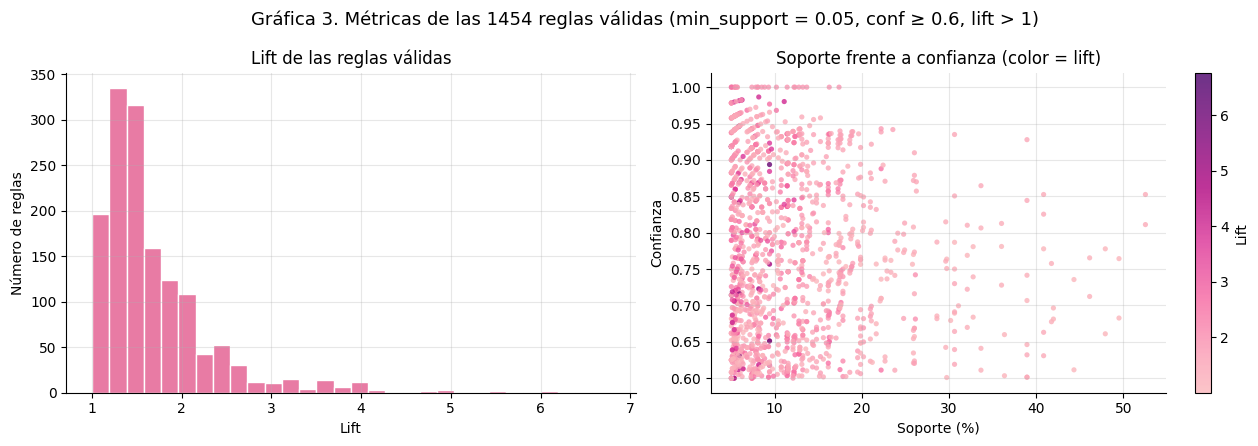

In [5]:
# Generación de reglas, métricas y filtros
reglas = association_rules(itemsets.drop(columns="Longitud"), metric="confidence", min_threshold=CONF_MIN)
print(f"Reglas candidatas con confianza ≥ {CONF_MIN}: {len(reglas)}")

atributos_de = lambda s: {i.split("=")[0] for i in s}
reglas["Antecedente"] = reglas["antecedents"].map(formatear)
reglas["Consecuente"] = reglas["consequents"].map(formatear)
items_regla = pd.Series([a | c for a, c in zip(reglas["antecedents"], reglas["consequents"])], index=reglas.index)
reglas["Trivial (Fare/Pclass)"] = items_regla.map(lambda s: atributos_de(s) <= {"Fare", "Pclass"})
reglas["Longitud"] = items_regla.map(len)

resumen = pd.Series({
    "Reglas con conf ≥ 0.6": len(reglas),
    "con lift > 1": int((reglas["lift"] > 1).sum()),
    "con lift ≤ 1 (asociación nula o negativa)": int((reglas["lift"] <= 1).sum()),
    "triviales Fare/Pclass": int(reglas["Trivial (Fare/Pclass)"].sum()),
    "con consecuente Survived=1": int(es_consecuente(reglas, "Survived=1").sum()),
    "con consecuente Survived=0": int(es_consecuente(reglas, "Survived=0").sum()),
}, name="Reglas")
display(resumen.to_frame())

COLUMNAS = ["Antecedente", "Consecuente", "support", "confidence", "lift", "leverage", "conviction"]
formato = {"support": "{:.3f}", "confidence": "{:.3f}", "lift": "{:.2f}", "leverage": "{:.3f}", "conviction": "{:.2f}"}
display(reglas[reglas["Trivial (Fare/Pclass)"]].nlargest(6, "confidence")[COLUMNAS]
        .style.format(formato).hide(axis="index").set_caption("Ejemplos de reglas triviales Fare/Pclass"))

# Reglas válidas: lift > 1 y no triviales
validas = reglas[(reglas["lift"] > 1) & ~reglas["Trivial (Fare/Pclass)"]].copy()
print(f"Reglas válidas (lift > 1, no triviales): {len(validas)}")

# Distribución de las métricas de las reglas válidas
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(validas["lift"], bins=30, color="#e87ba4", edgecolor="white")
axes[0].set_title("Lift de las reglas válidas")
axes[0].set_xlabel("Lift")
axes[0].set_ylabel("Número de reglas")
axes[1].scatter(validas["support"] * 100, validas["confidence"], c=validas["lift"], cmap=plt.matplotlib.colors.ListedColormap(plt.cm.RdPu(np.linspace(0.3, 1, 256))), s=14,
                edgecolor="none", alpha=0.8)
axes[1].set_title("Soporte frente a confianza (color = lift)")
axes[1].set_xlabel("Soporte (%)")
axes[1].set_ylabel("Confianza")
fig.colorbar(axes[1].collections[0], ax=axes[1], label="Lift")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.3)
fig.suptitle(f"Gráfica 3. Métricas de las {len(validas)} reglas válidas (min_support = 0.05, conf ≥ 0.6, lift > 1)", fontsize=13)
plt.tight_layout()
plt.show()

**Observaciones: reglas generadas**

- **1538 reglas con confianza ≥ 0.6:** **1458** tienen lift > 1, y **80** tienen lift ≤ 1, es decir, confianza alta sin asociación real (se analizan en la sección 7).
- **Solo 4 reglas son triviales en sentido estricto**, porque únicamente relacionan `Fare` con `Pclass`:
  - `Fare=0.00-7.91 → Pclass=3` (confianza **0.946**);
  - `Pclass=1 → Fare=31.00-512.33` y su inversa (lift **2.95**);
  - `Fare=7.91-14.45 → Pclass=3` (lift **1.12**).

  Confirman la redundancia medida en el notebook 1. Muchas otras reglas combinan `Fare` y `Pclass` con otros ítems.
- **Quedan 1454 reglas válidas** (lift > 1, no triviales).
  - La mayoría tiene lift entre **1 y 2**, con una cola larga hasta casi **7**.
  - En la dispersión, las reglas con mayor lift tienden a tener **soporte bajo** (5 %–10 %): las asociaciones más fuertes describen subgrupos pequeños.
- Al 5 % hay **44** reglas con consecuente `Survived=1` y **152** con `Survived=0`.

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">MINERÍA · INTERPRETACIÓN</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">6. Interpretación de las reglas</span></div>

Con 1454 reglas válidas, se necesita un criterio para presentar las relevantes. Además del lift, se eliminan las **reglas redundantes**: una regla $A \rightarrow C$ es redundante si existe una regla más simple $A' \rightarrow C$, con $A' \subset A$, cuya confianza es igual o mayor. Agregar ítems al antecedente sin mejorar la confianza no aporta conocimiento. La atención se centra en las reglas con consecuente `Survived`, que son el objetivo de la práctica.

In [6]:
# Reglas no redundantes y principales reglas por consecuente
def no_redundantes(df):
    """
    Elimina reglas redundantes: A → C lo es si existe A' ⊂ A con A' → C y confianza mayor o igual.

    Parámetros
    ----------
    df : pd.DataFrame
        Reglas de `association_rules` (columnas antecedents, consequents, confidence).

    Retorna
    -------
    pd.DataFrame
        Subconjunto de reglas que mejoran la confianza de todas sus sub-reglas presentes.
    """
    conf = {(a, c): v for a, c, v in zip(df["antecedents"], df["consequents"], df["confidence"])}
    conservar = [not any(a2 < a and c2 == c and v2 >= v for (a2, c2), v2 in conf.items())
                 for a, c, v in zip(df["antecedents"], df["consequents"], df["confidence"])]
    return df[conservar]


utiles = no_redundantes(validas)
print(f"Reglas válidas: {len(validas)} | no redundantes: {len(utiles)}")

for objetivo in ["Survived=1", "Survived=0"]:
    sub = utiles[es_consecuente(utiles, objetivo)]
    print(f"Reglas no redundantes → {objetivo}: {len(sub)}")
    display(sub.nlargest(10, "lift")[COLUMNAS].style.format(formato).hide(axis="index")
            .set_caption(f"Las 10 reglas → {objetivo} con mayor lift"))

# Reglas que no involucran Survived: estructura de la población
sin_surv = utiles[~(utiles["antecedents"].map(lambda s: any(i.startswith("Survived") for i in s))
                    | utiles["consequents"].map(lambda s: any(i.startswith("Survived") for i in s)))]
print(f"Reglas no redundantes sin Survived: {len(sin_surv)}")
display(sin_surv.nlargest(8, "lift")[COLUMNAS].style.format(formato).hide(axis="index")
        .set_caption("Reglas sin Survived con mayor lift (perfil de los pasajeros)"))

Reglas válidas: 1454 | no redundantes: 708
Reglas no redundantes → Survived=1: 26


Antecedente,Consecuente,support,confidence,lift,leverage,conviction
"Age=Adulto (30-49), Pclass=1, Sex=female",Survived=1,0.055,1.000,2.61,0.034,inf
"Fare=31.00-512.33, Pclass=1, Sex=female",Survived=1,0.094,0.977,2.54,0.057,26.49
"FamilySize=2-4, Fare=31.00-512.33, Sex=female",Survived=1,0.068,0.968,2.52,0.041,19.41
"Pclass=1, Sex=female",Survived=1,0.102,0.968,2.52,0.062,19.31
"Age=Adulto (30-49), Fare=31.00-512.33, Sex=female",Survived=1,0.055,0.925,2.41,0.032,8.16
"Pclass=2, Sex=female",Survived=1,0.079,0.921,2.40,0.046,7.80
"Embarked=C, Sex=female",Survived=1,0.072,0.877,2.28,0.040,5.00
"Fare=31.00-512.33, Sex=female",Survived=1,0.107,0.856,2.23,0.059,4.27
"Age=Adulto (30-49), FamilySize=2-4, Sex=female",Survived=1,0.055,0.831,2.16,0.030,3.64
"FamilySize=2-4, Sex=female",Survived=1,0.140,0.806,2.10,0.074,3.18


Reglas no redundantes → Survived=0: 67


Antecedente,Consecuente,support,confidence,lift,leverage,conviction
"Age=Adulto (30-49), Fare=0.00-7.91, Sex=male",Survived=0,0.051,0.978,1.59,0.019,17.66
"Age=Adulto (30-49), Fare=0.00-7.91",Survived=0,0.054,0.941,1.53,0.019,6.53
"Embarked=S, FamilySize=Solo, Fare=0.00-7.91, Sex=male",Survived=0,0.121,0.939,1.52,0.042,6.31
"Embarked=S, Fare=0.00-7.91, Sex=male",Survived=0,0.129,0.935,1.52,0.044,5.90
"FamilySize=5+, Pclass=3",Survived=0,0.056,0.926,1.50,0.019,5.18
"FamilySize=Solo, Fare=0.00-7.91, Sex=male",Survived=0,0.175,0.923,1.50,0.058,4.99
"Fare=0.00-7.91, Sex=male",Survived=0,0.186,0.922,1.50,0.062,4.94
"Age=Joven (18-29), FamilySize=Solo, Fare=7.91-14.45, Sex=male",Survived=0,0.074,0.917,1.49,0.024,4.61
"Age=Joven (18-29), Fare=7.91-14.45, Sex=male",Survived=0,0.081,0.911,1.48,0.026,4.33
"Embarked=S, FamilySize=Solo, Pclass=2, Sex=male",Survived=0,0.068,0.910,1.48,0.022,4.29


Reglas no redundantes sin Survived: 271


Antecedente,Consecuente,support,confidence,lift,leverage,conviction
"Embarked=S, FamilySize=2-4, Pclass=1",Fare=31.00-512.33,0.063,0.982,3.94,0.047,42.80
"FamilySize=2-4, Pclass=1, Sex=female",Fare=31.00-512.33,0.062,0.982,3.94,0.046,42.05
"FamilySize=2-4, Pclass=1",Fare=31.00-512.33,0.111,0.980,3.93,0.083,37.92
"Embarked=C, Fare=31.00-512.33",Pclass=1,0.077,0.932,3.85,0.057,11.21
"Age=Adulto (30-49), FamilySize=2-4, Fare=31.00-512.33",Pclass=1,0.054,0.906,3.74,0.039,8.03
"Age=Adulto (30-49), Pclass=1, Sex=female",Fare=31.00-512.33,0.051,0.918,3.69,0.037,9.20
"Pclass=1, Sex=female",Fare=31.00-512.33,0.097,0.915,3.67,0.070,8.82
"Embarked=Q, FamilySize=Solo","Fare=0.00-7.91, Pclass=3",0.055,0.860,3.63,0.040,5.44


In [7]:
# Corrida complementaria (min_support = 0.02) y sensibilidad a las edades imputadas
# 1) Reglas → Survived que solo aparecen al 2 % (evidencia débil)
itemsets_2 = fpgrowth(transacciones, min_support=0.02, use_colnames=True)
reglas_2 = association_rules(itemsets_2, metric="confidence", min_threshold=CONF_MIN)
reglas_2 = reglas_2[(reglas_2["lift"] > 1) & reglas_2["consequents"].isin([frozenset({"Survived=1"}), frozenset({"Survived=0"})])]
reglas_2 = no_redundantes(reglas_2[reglas_2["support"] < MIN_SUP]).copy()
reglas_2["Antecedente"] = reglas_2["antecedents"].map(formatear)
reglas_2["Consecuente"] = reglas_2["consequents"].map(formatear)
reglas_2["Pasajeros"] = (reglas_2["support"] * len(transacciones)).round().astype(int)
print(f"Reglas → Survived no redundantes con soporte entre 2 % y 5 %: {len(reglas_2)} "
      f"(→ Survived=1: {es_consecuente(reglas_2, 'Survived=1').sum()})")
display(reglas_2[es_consecuente(reglas_2, "Survived=1")].nlargest(8, "lift")[COLUMNAS + ["Pasajeros"]]
        .style.format(formato).hide(axis="index").set_caption("Evidencia débil: reglas → Survived=1 con soporte entre 2 % y 5 %"))

# 2) Sensibilidad: reglas → Survived con Age, sin las 177 edades imputadas
observadas = transacciones[~tabla_limpia["EdadImputada"]].reset_index(drop=True)
reglas_obs = association_rules(fpgrowth(observadas, min_support=MIN_SUP, use_colnames=True),
                               metric="confidence", min_threshold=CONF_MIN)
con_age = lambda df: df[df["antecedents"].map(lambda s: any(i.startswith("Age=") for i in s))
                        & df["consequents"].isin([frozenset({"Survived=1"}), frozenset({"Survived=0"})])]
comparacion = con_age(utiles)[["antecedents", "consequents", "confidence", "lift"]].merge(
    con_age(reglas_obs)[["antecedents", "consequents", "confidence", "lift"]],
    on=["antecedents", "consequents"], how="left", suffixes=(" (891)", " (sin imputadas)"))
comparacion.insert(0, "Regla", comparacion["antecedents"].map(formatear) + " → " + comparacion["consequents"].map(formatear))
comparacion = comparacion.drop(columns=["antecedents", "consequents"])
print(f"Reglas → Survived con Age (todas las filas): {len(comparacion)} | siguen apareciendo sin las imputadas: "
      f"{comparacion['lift (sin imputadas)'].notna().sum()}")
display(comparacion.sort_values("lift (891)", ascending=False).head(10).style.format(
    {c: "{:.3f}" for c in comparacion.columns if c != "Regla"}, na_rep="no aparece").hide(axis="index")
    .set_caption("Sensibilidad: reglas con Age, con y sin las 714 edades observadas"))
desaparece = comparacion[comparacion["lift (sin imputadas)"].isna()]
print(f"Regla que desaparece sin las imputadas: {desaparece['Regla'].tolist()} | "
      f"lift con todas las filas: {desaparece['lift (891)'].round(3).tolist()}")

# 3) Reglas puntuales del EDA, calculadas directamente (sin umbral de confianza)
def metricas(antecedente, consecuente):
    """
    Calcula soporte, confianza y lift de una regla concreta sobre las transacciones.

    Parámetros
    ----------
    antecedente : list of str
        Ítems del antecedente.
    consecuente : str
        Ítem del consecuente.

    Retorna
    -------
    dict
        Regla, número de pasajeros con el antecedente, soporte, confianza y lift.
    """
    a = transacciones[antecedente].all(axis=1)
    ac = a & transacciones[consecuente]
    conf = ac.sum() / a.sum()
    return {"Regla": f"{', '.join(antecedente)} → {consecuente}", "Pasajeros con A": int(a.sum()),
            "Soporte": ac.mean(), "Confianza": conf, "Lift": conf / transacciones[consecuente].mean()}


puntuales = pd.DataFrame([
    metricas(["Sex=male", "Age=Niño (0-12)"], "Survived=1"),
    metricas(["Sex=male", "Age=Adulto (30-49)"], "Survived=1"),
    metricas(["Sex=male"], "Survived=1"),
    metricas(["Embarked=Q"], "Survived=1"),
    metricas(["Sex=female", "Pclass=3"], "Survived=1"),
    metricas(["FamilySize=5+"], "Survived=0"),
])
display(puntuales.style.format({"Soporte": "{:.3f}", "Confianza": "{:.3f}", "Lift": "{:.2f}"}).hide(axis="index")
        .set_caption("Reglas puntuales del EDA, sin umbral de confianza"))

Reglas → Survived no redundantes con soporte entre 2 % y 5 %: 177 (→ Survived=1: 75)

Antecedente,Consecuente,support,confidence,lift,leverage,conviction,Pasajeros
"Age=Adulto (30-49), FamilySize=2-4, Fare=31.00-512.33, Sex=female",Survived=1,0.036,1.000,2.61,0.022,inf,32
"FamilySize=Solo, Fare=31.00-512.33, Sex=female",Survived=1,0.031,1.000,2.61,0.019,inf,28
"Age=Adulto (30-49), FamilySize=2-4, Pclass=1, Sex=female",Survived=1,0.033,1.000,2.61,0.020,inf,29
"Age=Adulto (30-49), Embarked=S, Pclass=1, Sex=female",Survived=1,0.028,1.000,2.61,0.017,inf,25
"Age=Adulto (30-49), FamilySize=Solo, Pclass=1, Sex=female",Survived=1,0.022,1.000,2.61,0.014,inf,20
"Embarked=C, FamilySize=2-4, Pclass=1, Sex=female",Survived=1,0.026,1.000,2.61,0.016,inf,23
"Embarked=C, Fare=31.00-512.33, Sex=female",Survived=1,0.047,1.000,2.61,0.029,inf,42
"Age=Adulto (30-49), Embarked=C, Pclass=1, Sex=female",Survived=1,0.026,1.000,2.61,0.016,inf,23


Reglas → Survived con Age (todas las filas): 36 | siguen apareciendo sin las imputadas: 35


Regla,confidence (891),lift (891),confidence (sin imputadas),lift (sin imputadas)
"Age=Adulto (30-49), Pclass=1, Sex=female → Survived=1",1.000,2.605,1.000,2.462
"Age=Adulto (30-49), Fare=31.00-512.33, Sex=female → Survived=1",0.925,2.409,0.909,2.238
"Age=Adulto (30-49), FamilySize=2-4, Sex=female → Survived=1",0.831,2.164,0.826,2.034
"Age=Adulto (30-49), Sex=female → Survived=1",0.791,2.061,0.783,1.927
"Age=Adulto (30-49), Fare=31.00-512.33, Pclass=1 → Survived=1",0.713,1.856,0.746,1.837
"Age=Adulto (30-49), Fare=31.00-512.33 → Survived=1",0.677,1.765,0.697,1.717
"Age=Adulto (30-49), Pclass=1 → Survived=1",0.641,1.670,0.701,1.726
"Age=Adulto (30-49), Fare=0.00-7.91, Sex=male → Survived=0",0.978,1.588,0.974,1.640
"Age=Adulto (30-49), Fare=0.00-7.91 → Survived=0",0.941,1.527,0.976,1.643
"Age=Joven (18-29), FamilySize=Solo, Fare=7.91-14.45, Sex=male → Survived=0",0.917,1.488,0.909,1.531


Regla que desaparece sin las imputadas: ['Age=Joven (18-29), FamilySize=Solo, Fare=7.91-14.45, Pclass=3 → Survived=0'] | lift con todas las filas: [1.407]


Regla,Pasajeros con A,Soporte,Confianza,Lift
"Sex=male, Age=Niño (0-12) → Survived=1",41,0.026,0.561,1.46
"Sex=male, Age=Adulto (30-49) → Survived=1",194,0.047,0.216,0.56
Sex=male → Survived=1,577,0.122,0.189,0.49
Embarked=Q → Survived=1,77,0.034,0.390,1.02
"Sex=female, Pclass=3 → Survived=1",144,0.081,0.500,1.30
FamilySize=5+ → Survived=0,62,0.058,0.839,1.36


**Observaciones: interpretación**

*Reglas no redundantes.* El filtro reduce las **1454** reglas válidas a **708** (26 → `Survived=1`, 67 → `Survived=0`, 271 sin `Survived`).

*Quién sobrevivió (→ `Survived=1`):*
- **Ser mujer de 1.ª o 2.ª clase es el patrón dominante.**
  - `{Pclass=1, Sex=female} → Survived=1`: confianza **0.968**, lift **2.52**, soporte **10.2 %**.
  - `{Pclass=2, Sex=female}`: confianza **0.921**, lift **2.40**.
  - Con edad adulta (30-49), la confianza de las mujeres de 1.ª llega a **1.000** (lift **2.61**, el máximo posible: $1/0.3838$).
- **La tarifa alta y la familia pequeña refuerzan el patrón en las mujeres:**
  - `{Fare=31.00-512.33, Pclass=1, Sex=female}`: confianza **0.977**;
  - `{FamilySize=2-4, Sex=female}`: confianza **0.806**, lift **2.10** y el mayor soporte de la lista (**14.0 %**).
- `{Embarked=C, Sex=female}` (confianza **0.877**, lift **2.28**) parece un efecto del puerto, pero la sección 7 lo matiza.

*Quién no sobrevivió (→ `Survived=0`):*
- **Hombres con tarifa baja:**
  - `{Fare=0.00-7.91, Sex=male}`: confianza **0.922**, soporte **18.6 %**;
  - con edad adulta (30-49): confianza **0.978**.
- **Familias numerosas de 3.ª clase:** `{FamilySize=5+, Pclass=3}`, con confianza **0.926**.
- Los lifts son menores (máximo **1.59**) porque el lift de una regla → `Survived=0` no puede superar $1/0.6162 \approx 1.62$. **No se comparan directamente** con los lifts de `Survived=1`.

*Perfil de los pasajeros (reglas sin `Survived`):* las reglas con mayor lift describen la estructura social del barco.
- `{FamilySize=2-4, Pclass=1} → Fare=31.00-512.33` (confianza **0.980**, lift **3.93**).
- `{Embarked=Q, FamilySize=Solo} → {Fare=0.00-7.91, Pclass=3}` (lift **3.63**): los pasajeros embarcados en Queenstown viajaban solos y en la tarifa más baja.

*Corrida complementaria (2 %), evidencia débil:*
- Aparecen **177** reglas → `Survived` adicionales, **75** de ellas → `Survived=1`.
- Las de mayor lift son variantes más específicas del patrón mujer–1.ª clase, con confianza **1.000**, pero respaldadas por solo **20 a 42** pasajeras.
- **El patrón de los niños varones no aparece ni siquiera al 2 %.** Calculada directamente, `{Sex=male, Age=Niño} → Survived=1` tiene soporte **0.026**, lift **1.46** y confianza **0.561** (41 niños). Es una asociación positiva clara (contra **0.189** en todos los hombres y **0.216** en los adultos), pero **no alcanza la confianza mínima de 0.6**.
- **El umbral de confianza oculta asociaciones relevantes cuando el consecuente es poco frecuente.** También `{Sex=female, Pclass=3} → Survived=1` tiene confianza **0.500** con lift **1.30**.

*Sensibilidad a las edades imputadas:*
- **De las 36 reglas → `Survived` con `Age`, 35 siguen apareciendo** al excluir las 177 edades imputadas, con lifts parecidos (p. ej. **2.605 → 2.462** en la regla de las mujeres adultas de 1.ª).
- La única que desaparece es `{Age=Joven, FamilySize=Solo, Fare=7.91-14.45, Pclass=3} → Survived=0` (lift **1.407**). Justo el grupo de los hombres de 3.ª clase imputados con **26** años: **esa regla se apoya en la imputación** y se descarta como hallazgo.

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">MINERÍA · EVALUACIÓN</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">7. Evaluación crítica</span></div>

Una regla con buenas métricas no es necesariamente un hallazgo. Se revisan cuatro problemas: el efecto de los **ítems dominantes** sobre la confianza, las **reglas triviales o redundantes**, el **desbalance** de `Survived` y la diferencia entre **correlación y causalidad**.

In [8]:
# Efecto de los ítems dominantes y del desbalance
DOMINANTES = soporte_item[soporte_item > 0.5].index
cons_dominante = reglas["consequents"].map(lambda s: s <= set(DOMINANTES))
print(f"Ítems con soporte > 50 %: {list(DOMINANTES)}")
print(f"Reglas válidas (lift > 1) con consecuente formado solo por ítems dominantes: "
      f"{(cons_dominante & (reglas['lift'] > 1)).sum()} de {(reglas['lift'] > 1).sum()} "
      f"({(cons_dominante & (reglas['lift'] > 1)).sum() / (reglas['lift'] > 1).sum() * 100:.2f} %)")
display(reglas.loc[reglas["lift"] <= 1, "Consecuente"].value_counts().rename("Reglas con conf ≥ 0.6 y lift ≤ 1")
        .rename_axis("Consecuente").to_frame())
display(reglas[reglas["lift"] <= 1].nsmallest(5, "lift")[COLUMNAS].style.format(formato).hide(axis="index")
        .set_caption("Confianza alta sin asociación: las 5 reglas con menor lift"))

# Lift máximo posible según el consecuente (desbalance de Survived)
display(pd.DataFrame({"Soporte del consecuente": soporte_item[["Survived=1", "Survived=0"]],
                      "Lift máximo posible (1 / soporte)": 1 / soporte_item[["Survived=1", "Survived=0"]]}).round(3))

# Composición de los embarcados en C (correlación frente a causalidad)
emb_c = tabla_limpia["Embarked"] == "C"
print(f"Embarcados en C: {emb_c.sum()} | de 1.ª clase: {(tabla_limpia.loc[emb_c, 'Pclass'] == 1).mean() * 100:.2f} % "
      f"(global {(tabla_limpia['Pclass'] == 1).mean() * 100:.2f} %) | mujeres: "
      f"{(tabla_limpia.loc[emb_c, 'Sex'] == 'female').mean() * 100:.2f} % (global {(tabla_limpia['Sex'] == 'female').mean() * 100:.2f} %)")
print(f"Tasa de supervivencia de mujeres de 1.ª clase por puerto: "
      f"{(tabla_limpia[(tabla_limpia['Pclass'] == 1) & (tabla_limpia['Sex'] == 'female')].groupby('Embarked')['Survived'].mean() * 100).round(2).to_dict()}")

Ítems con soporte > 50 %: ['Pclass=3', 'FamilySize=Solo', 'Survived=0', 'Sex=male', 'Embarked=S']
Reglas válidas (lift > 1) con consecuente formado solo por ítems dominantes: 1141 de 1458 (78.26 %)


,Reglas con conf ≥ 0.6 y lift ≤ 1
Consecuente,
Embarked=S,74
Sex=male,4
Survived=0,2


Antecedente,Consecuente,support,confidence,lift,leverage,conviction
"Sex=female, Survived=1",Embarked=S,0.159,0.609,0.84,-0.030,0.70
"Pclass=3, Sex=female",Embarked=S,0.099,0.611,0.84,-0.018,0.71
"Fare=31.00-512.33, Sex=female",Embarked=S,0.076,0.613,0.84,-0.014,0.71
"FamilySize=Solo, Fare=0.00-7.91",Embarked=S,0.145,0.614,0.85,-0.026,0.71
"Age=Adulto (30-49), Pclass=1",Embarked=S,0.081,0.615,0.85,-0.014,0.71


,Soporte del consecuente,Lift máximo posible (1 / soporte)
Survived=1,0.384,2.605
Survived=0,0.616,1.623


Embarcados en C: 168 | de 1.ª clase: 50.60 % (global 24.24 %) | mujeres: 43.45 % (global 35.24 %)
Tasa de supervivencia de mujeres de 1.ª clase por puerto: {'C': 97.67, 'Q': 100.0, 'S': 96.0}


**Observaciones: evaluación crítica**

*1. Ítems dominantes e inflación de la confianza*
- **El 78.26 % de las reglas válidas (1141 de 1458) tiene como consecuente solo ítems con soporte > 50 %:** `Embarked=S`, `Sex=male`, `Survived=0`, `FamilySize=Solo` y `Pclass=3`. Son reglas fáciles de satisfacer, porque el consecuente ya es mayoritario.
- **Hay 80 reglas con confianza ≥ 0.6 pero lift ≤ 1. En 74 de ellas el consecuente es `Embarked=S`.**
  - Por ejemplo, `{Sex=female, Survived=1} → Embarked=S` tiene confianza **0.609**, pero lift **0.84** y leverage **−0.030**: las sobrevivientes embarcaron en S *menos* de lo esperado.
  - Filtrar solo por confianza las habría presentado como hallazgos. **El lift es imprescindible.**

*2. Reglas triviales y redundantes*
- Las **4** reglas triviales `Fare` ↔ `Pclass` reflejan la redundancia ya medida en el notebook 1 (V = 0.54).
- **El filtro de redundancia reduce las reglas a menos de la mitad (1454 → 708):** muchas reglas solo agregan al antecedente ítems que no mejoran la confianza.

*3. Desbalance de `Survived`*
- **El lift máximo posible es 2.605 para `Survived=1` y solo 1.623 para `Survived=0`.** Por eso los rankings por lift se hicieron **por separado** para cada consecuente.
- **La confianza mínima de 0.6 penaliza a `Survived=1`** (38.38 % de base): `{Sex=male, Age=Niño} → Survived=1` (lift **1.46**) y `{Sex=female, Pclass=3} → Survived=1` (lift **1.30**) son asociaciones positivas que quedan fuera.

*4. Correlación no es causalidad*
- `{Embarked=C, Sex=female} → Survived=1` tiene lift **2.28**, pero **el 50.60 % de los embarcados en C es de 1.ª clase** (contra 24.24 % global) y el **43.45 %** son mujeres (contra 35.24 %).
- **Dentro de las mujeres de 1.ª clase, la supervivencia casi no cambia según el puerto** (**97.67 %** en C, **96.00 %** en S).
- La asociación del puerto con la supervivencia se explica por **la composición de clase y sexo** (variables de confusión), no por el puerto en sí.
- En general, las reglas describen **co-ocurrencias** en los datos. No dicen *por qué* sobrevivió alguien: la prioridad de mujeres y niños en los botes o la ubicación de las cabinas por clase son explicaciones externas, no derivadas de las reglas.

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">8. Conclusiones y limitaciones</span></div>

### Conclusiones

1. **FP-Growth fue adecuado para el problema:** transacciones densas (7 de 22 ítems por pasajero), soportes bajos y necesidad de un resultado exacto. Con $s$ = 5 % encontró **569 itemsets** frecuentes, uno de ellos de longitud 7, y **1538 reglas** con confianza ≥ 0.6.
2. **El sexo es el eje de la supervivencia, modulado por la clase.**
   - `{Pclass=1, Sex=female} → Survived=1` (confianza **0.968**, lift **2.52**) y `{Pclass=2, Sex=female} → Survived=1` (**0.921**, **2.40**) son las reglas más fuertes con respaldo amplio.
   - En el otro extremo, `{Fare=0.00-7.91, Sex=male} → Survived=0` (**0.922**) y `{FamilySize=5+, Pclass=3} → Survived=0` (**0.926**).
3. **Viajar en una familia pequeña (2-4) se asocia con mayor supervivencia en las mujeres**, mientras que **las familias de 5 o más de 3.ª clase casi no sobrevivieron.**
4. **Los niños varones sobrevivieron más que los hombres adultos** (lift **1.46** frente a **0.56**), pero esa asociación **no supera la confianza mínima**. Hay que buscarla explícitamente.
5. **El lift y el filtro de redundancia fueron indispensables:** sin ellos, la lista estaría dominada por reglas hacia ítems mayoritarios (78.26 %), incluidas 80 con asociación nula o negativa.

### Limitaciones

- **Datos:** solo `train.csv` (891 pasajeros, unos dos tercios de los del dataset de Kaggle). `Cabin` se descartó por su 77 % de faltantes, así que se pierde la posible señal de la ubicación a bordo.
- **Imputación:** 177 edades (19.87 %) se imputaron por `Title` × `Pclass`. La prueba de sensibilidad mostró que 35 de 36 reglas con `Age` se mantienen, y se descartó la única que dependía de la imputación.
- **Discretización:** los resultados dependen de los cortes de `Age` (etapas de vida) y `Fare` (cuartiles). Otros cortes producirían otros ítems y otras reglas. `Age=Adolescente` (4.94 %) quedó por debajo del soporte mínimo.
- **Umbrales:** $s$ = 5 % y confianza ≥ 0.6 son decisiones del análisis. Con el desbalance de `Survived`, la confianza mínima oculta asociaciones positivas hacia `Survived=1`. Las reglas de la corrida al 2 % se apoyan en 20–42 pasajeros y son **evidencia débil**.
- **Interpretación:** las reglas son asociaciones, no relaciones causales, y algunas (como las de `Embarked`) se explican por variables de confusión. Tampoco se aplicó una corrección por comparaciones múltiples: con cientos de reglas, algunas asociaciones pueden ser producto del azar.

---

<div style="opacity:.72;font-size:12.5px;">
Antes de entregar: comprueba que el notebook corre de principio a fin con <b>Kernel &gt; Restart &amp; Run All</b> sin errores.
</div>